### Mengambil data
Karena Google Colab dan Kaggle adalah dua aplikasi yang berbeda, diperlukan API token untuk mengunduh data dari kaggle masuk ke dalam data Google Colab

In [ ]:
import os
from google.colab import userdata

# Mengambil kredensial dari Secrets Colab
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Verifikasi instalasi kaggle API
!pip install -q kaggle

In [ ]:
# Dataset
dataset_slug = "mlg-ulb/creditcardfraud"

# Download dataset
!kaggle datasets download -d {dataset_slug}

# Unzip otomatis
import zipfile
with zipfile.ZipFile(f"{dataset_slug.split('/')[-1]}.zip", 'r') as zip_ref:
    zip_ref.extractall('./data')

print("Dataset berhasil diunduh dan diekstrak ke folder /data")

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset berhasil diunduh dan diekstrak ke folder /data


In [ ]:
import pandas as pd

df = pd.read_csv('./data/creditcard.csv')
print(f"Data Loaded: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Data Loaded: 284807 rows and 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Analisis data

Transaksi Normal: 284315
Transaksi Fraud: 492
Persentase Fraud: 0.173%


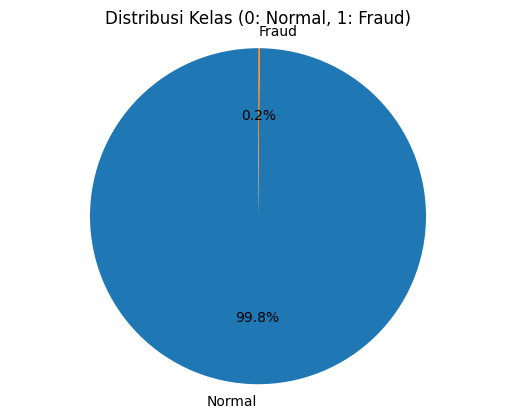

In [ ]:
import matplotlib.pyplot as plt

# Menghitung jumlah fraud (1) vs normal (0)
fraud_count = df['Class'].value_counts()
print(f"Transaksi Normal: {fraud_count[0]}")
print(f"Transaksi Fraud: {fraud_count[1]}")
print(f"Persentase Fraud: {round(fraud_count[1]/len(df)*100, 3)}%")

plt.pie(fraud_count.values, labels=['Normal', 'Fraud'], autopct='%1.1f%%', startangle=90)
plt.axis('equal') # Ensure pie chart is circular
plt.title('Distribusi Kelas (0: Normal, 1: Fraud)')
plt.show()

Terlihat bahwa data dengan kelas Fraud sangat sedikit (tentunya kita juga tidak menginginkan kejahatan yang banyak), namun hal ini akan berdampak kepada training test kita yang akan menghadapi data imbalance

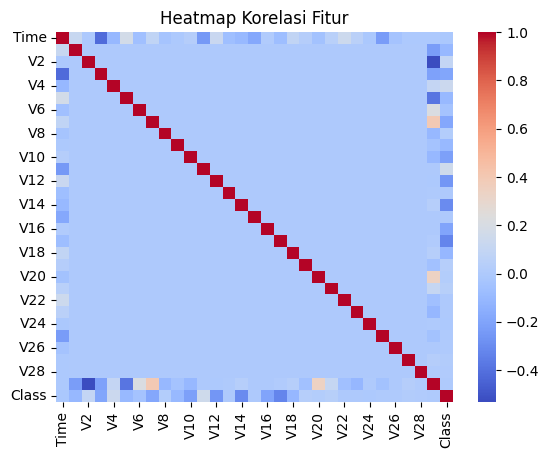

10 Fitur dengan Korelasi Terkuat (Negatif & Positif):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64
------------------------------
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


In [ ]:
import seaborn as sns

sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Heatmap Korelasi Fitur')
plt.show()

# Menghitung korelasi terhadap kolom 'Class'
correlations = df.corr()['Class'].sort_values()

print("10 Fitur dengan Korelasi Terkuat (Negatif & Positif):")
print(correlations.head(5))  # Paling negatif
print("-" * 30)
print(correlations.tail(6))  # Paling positif (termasuk Class itu sendiri)

Dari matriks korelasi, diperoleh fitur dengan korelasinya yang paling tinggi adalah V17 (korelasi negatif). Maka dari itu, pada langkah selanjutnya, kita akan mencoba bereksplorasi pada fitur tersebut

/tmp/ipykernel_22473/2963105442.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['V17'][df['Class'] == 1], color='r', label='Fraud')
/tmp/ipykernel_22473/2963105442.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['V17'][df['Class'] == 0], color='g', label='Normal')


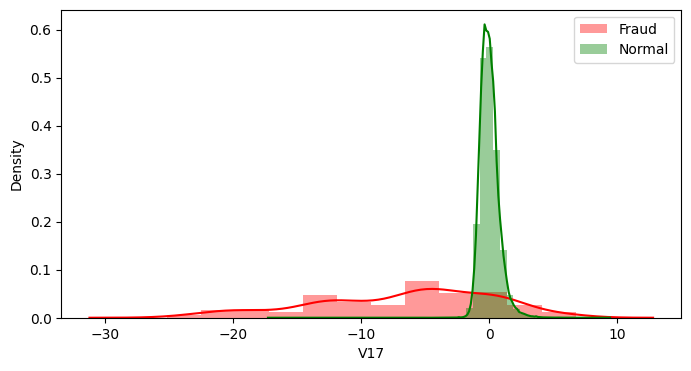

In [ ]:
import seaborn as sns
# Contoh membandingkan distribusi fitur V17 (paling kuat/biasanya sangat berpengaruh)
fig, ax = plt.subplots(figsize=(8,4))
sns.distplot(df['V17'][df['Class'] == 1], color='r', label='Fraud')
sns.distplot(df['V17'][df['Class'] == 0], color='g', label='Normal')
plt.legend()
plt.show()

### Mengolah data

Fitur V1-V28 sudah diskalakan (hasil PCA), tapi Amount dan Time belum. Kita harus menyamakannya supaya model tidak menganggap transaksi bernilai 1000 lebih penting daripada fitur V17 yang bernilai -20

In [ ]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Hapus kolom asli yang tidak diskalakan
df.drop(['Time','Amount'], axis=1, inplace=True)

Mengerjakan train-test split dengan Stratified Shuffle Split karena data sangat highly imbalanced

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

X = df.drop('Class', axis=1)
y = df['Class']

# Menggunakan Stratified agar rasio fraud di Train dan Test sama dengan data asli
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(X, y):
    # Kita buat variabel 'original' agar tidak tertukar
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# Gabungkan kembali sementara untuk proses filtering
train_df = pd.concat([original_Xtrain, original_ytrain], axis=1)
fraud_df = train_df.loc[train_df['Class'] == 1]
non_fraud_df = train_df.loc[train_df['Class'] == 0][:len(fraud_df)]

# Membuat dataset baru yang seimbang (50/50)
new_df_train = pd.concat([fraud_df, non_fraud_df]).sample(frac=1, random_state=42)

# Data untuk LATIHAN (Sudah Seimbang)
X_train = new_df_train.drop('Class', axis=1).values
y_train = new_df_train['Class'].values

# Data untuk UJIAN (Tetap Timpang/Realistis)
X_test = original_Xtest.values
y_test = original_ytest.values

print(f"Jumlah Data Train (Seimbang): {len(X_train)} (Fraud: {sum(y_train)})")
print(f"Jumlah Data Test (Realistis): {len(X_test)} (Fraud: {sum(y_test)})")

Jumlah Data Train (Seimbang): 788 (Fraud: 394)
Jumlah Data Test (Realistis): 56962 (Fraud: 98)


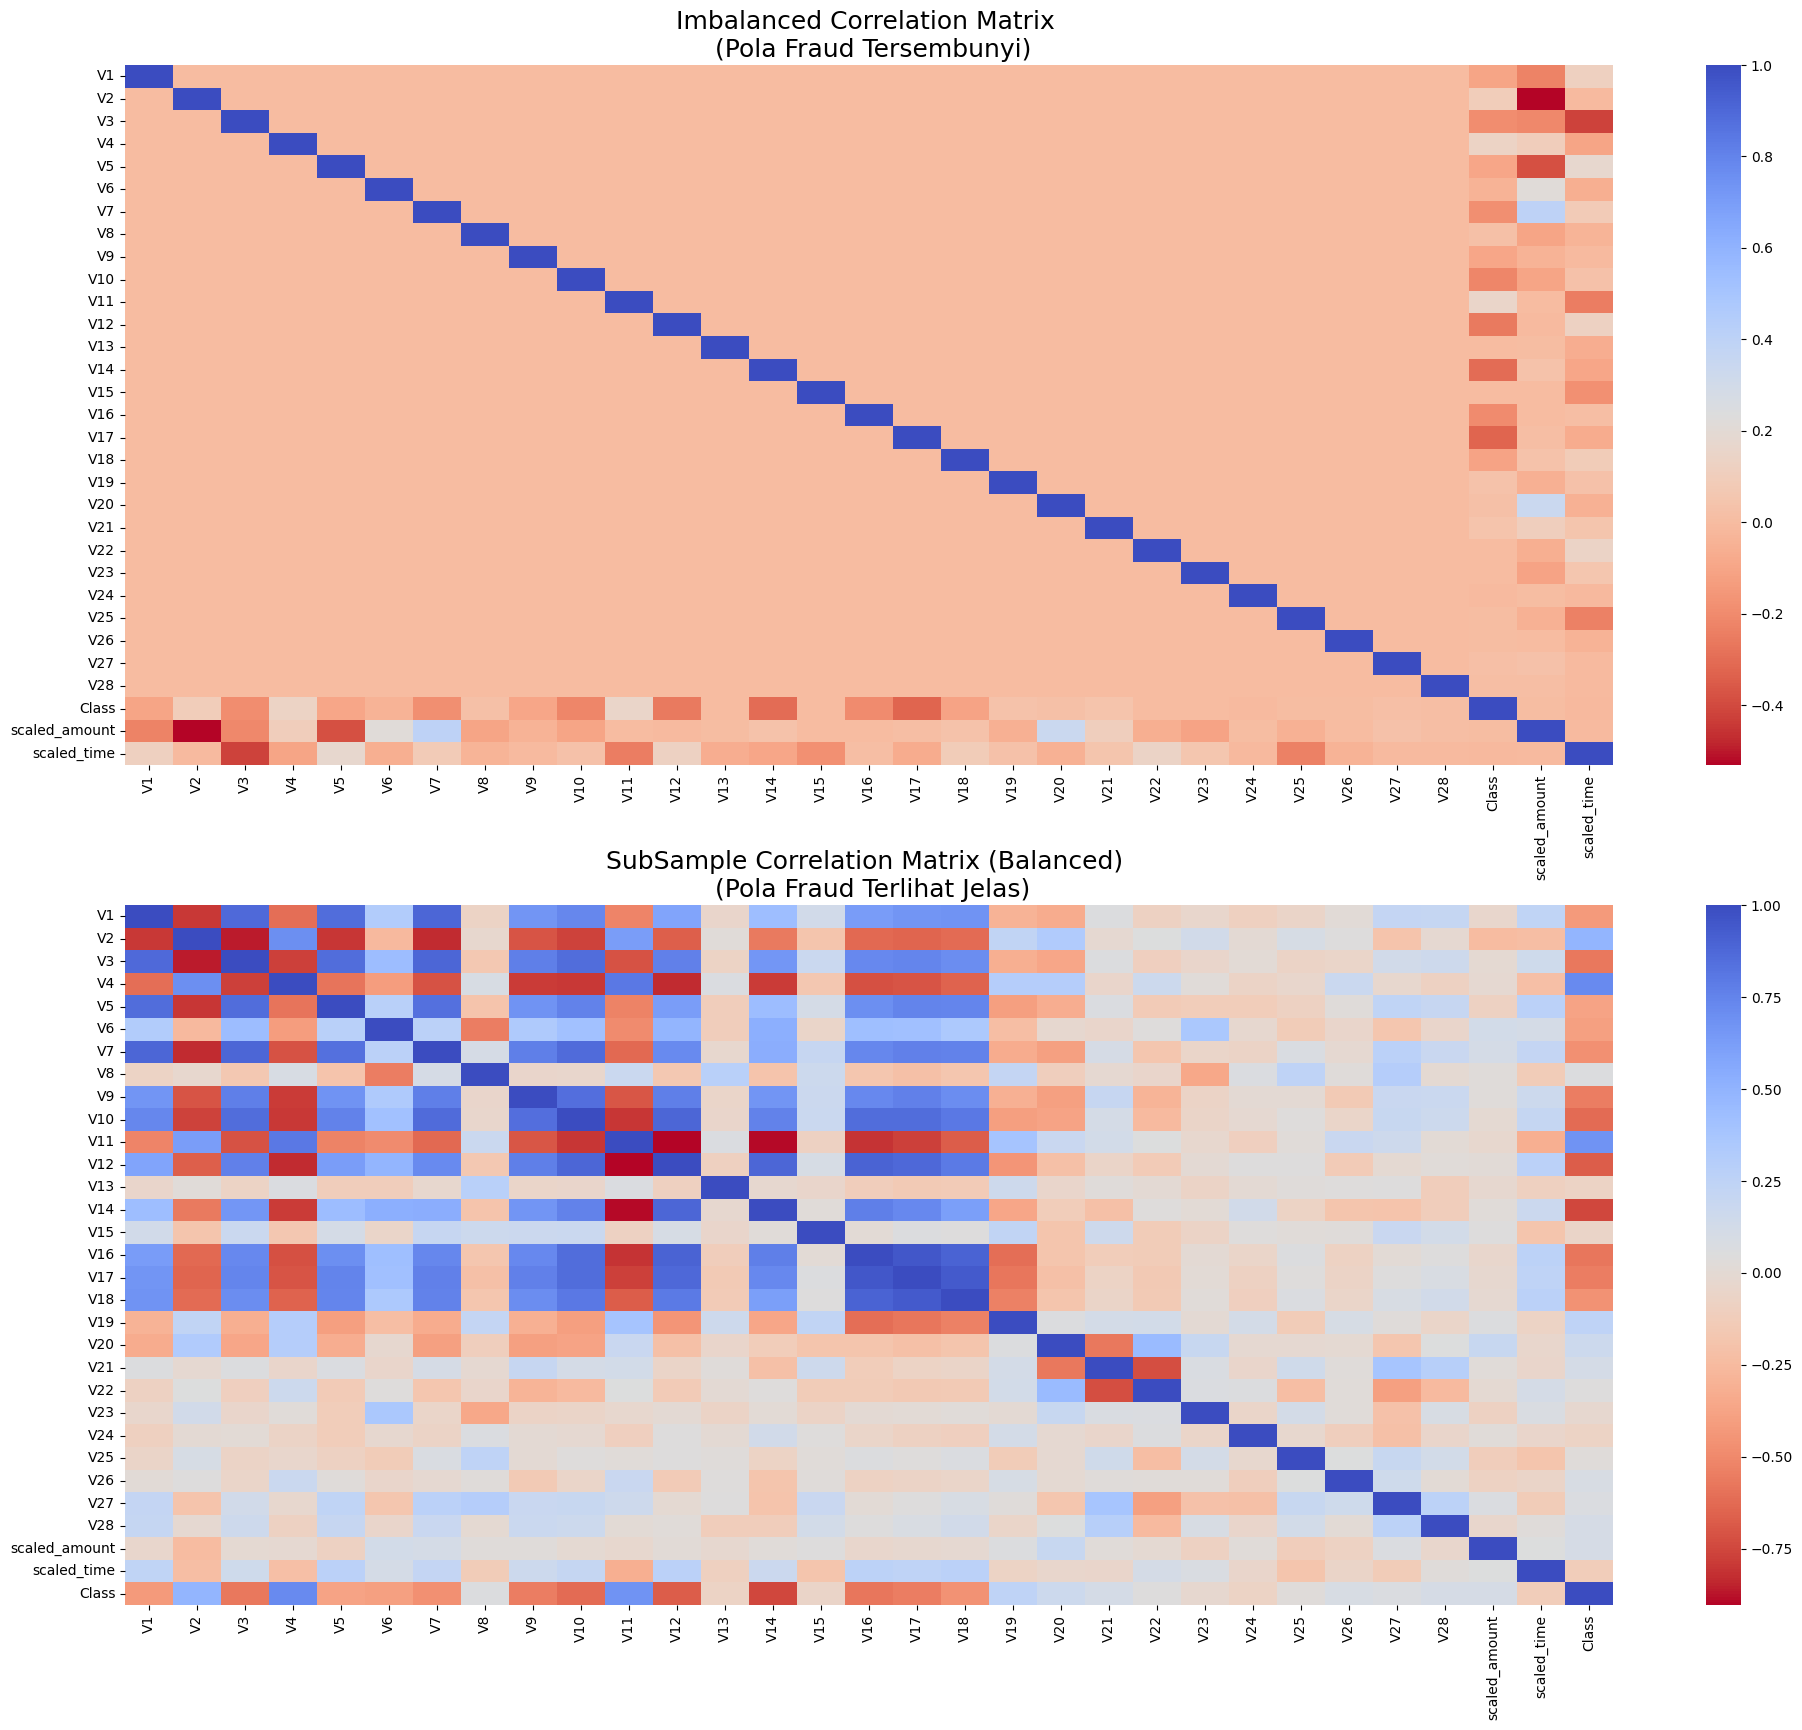

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# 1. Matriks korelasi data ASLI (Gunakan dataframe awal)
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (Pola Fraud Tersembunyi)", fontsize=18)

# 2. Matriks korelasi data SEIMBANG (Gunakan hasil sampling data train)
new_corr = new_df_train.corr()
sns.heatmap(new_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title("SubSample Correlation Matrix (Balanced) \n (Pola Fraud Terlihat Jelas)", fontsize=18)

plt.show()

### Hasil Klasifikasi

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

# Evaluasi menggunakan Cross-Validation (5-fold)
for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f"Classifier: {key} memiliki skor rata-rata {round(training_score.mean(), 3) * 100}%")

Classifier: LogisiticRegression memiliki skor rata-rata 94.8%
Classifier: KNearest memiliki skor rata-rata 94.19999999999999%
Classifier: Support Vector Classifier memiliki skor rata-rata 93.30000000000001%
Classifier: DecisionTreeClassifier memiliki skor rata-rata 91.0%


KNN (94.3%): Algoritma ini sangat bergantung pada "kedekatan" data. Jika ada transaksi fraud baru yang polanya sedikit bergeser (anomali baru), KNN mungkin akan gagal menangkapnya. KNN juga lambat saat memproses data besar di tahap produksi (inference time).

Analisis: Meskipun KNN memberikan akurasi sedikit lebih tinggi, Logistic Regression (94.0%) adalah pilihan yang lebih bertanggung jawab dan robust untuk sistem Fraud Detection. Hal ini dikarenakan efisiensi komputasi Logistic Regression yang jauh lebih baik untuk data skala besar dan kemampuannya dalam menyediakan interpretasi fitur yang lebih jelas, yang sangat krusial dalam audit keamanan siber perbankan.

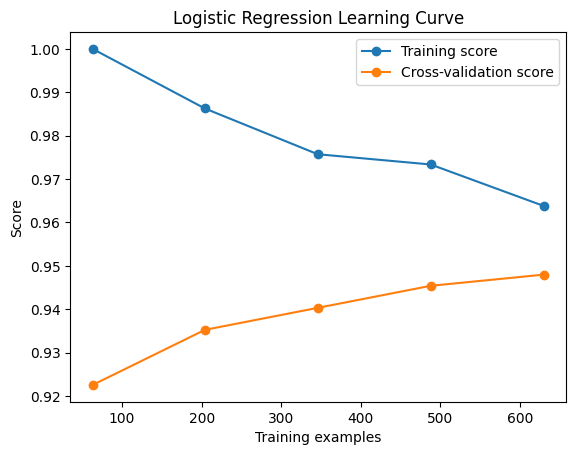

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5))

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.show()

# Contoh plotting untuk Logistic Regression
plot_learning_curve(classifiers["LogisiticRegression"], X_train, y_train, "Logistic Regression Learning Curve")

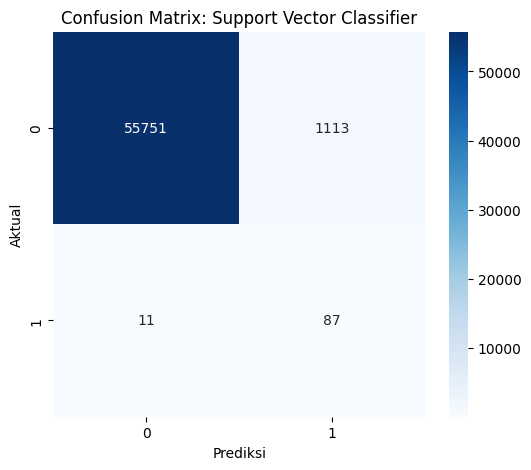

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Ambil salah satu model terbaik, misal SVC
y_pred_svc = classifiers["Support Vector Classifier"].predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix: Support Vector Classifier')
plt.show()

True Negative (Kiri Atas): Transaksi normal yang benar ditebak normal.

False Positive (Kanan Atas): Transaksi normal yang salah dituduh fraud (Nasabah terganggu).

False Negative (Kiri Bawah): INI YANG PALING BERBAHAYA. Transaksi fraud yang lolos sebagai normal. Jika angka ini tinggi, model gagal secara fungsional meskipun akurasinya 93%.

True Positive (Kanan Bawah): Transaksi fraud yang berhasil ditangkap.

### Hyperparameter Tuning menggunakan GridSearchCV

Hyperparameter Tuning merupakan tahap tambahan dalam siklus pengembangan model machine learning yang bertujuan untuk mengoptimalkan performa algoritma melalui pencarian kombinasi parameter terbaik secara otomatis. Berbeda dengan parameter model yang dipelajari selama proses training (seperti bobot dan bias), hyperparameter adalah konfigurasi eksternal yang ditentukan sebelum proses belajar dimulai—seperti nilai regularisasi (C) atau jenis kernel. Tanpa tahapan ini, model hanya akan berjalan pada pengaturan standar (default) yang belum tentu mampu menangkap karakteristik spesifik dari dataset fraud detection yang memiliki kompleksitas fitur tinggi.

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Tuning untuk Logistic Regression
log_reg_params = {
    "penalty": ['l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000] # Default-nya biasanya cuma 100
}
grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)
log_reg = grid_log_reg.best_estimator_

# 2. Tuning untuk SVC
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(X_train, y_train)
svc = grid_svc.best_estimator_

print(f"Best Estimator LogReg: {log_reg}")
print(f"Best Estimator SVC: {svc}")

Best Estimator LogReg: LogisticRegression(C=100, max_iter=1000)
Best Estimator SVC: SVC(C=0.5, kernel='linear')


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Gunakan model hasil Tuning (misal SVC) untuk prediksi data test asli
y_pred_final = svc.predict(X_test)

print("--- Laporan Klasifikasi Akhir ---")
print(classification_report(y_test, y_pred_final))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_final)}")

--- Laporan Klasifikasi Akhir ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.92      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.93      0.52     56962
weighted avg       1.00      0.95      0.97     56962

ROC AUC Score: 0.9339919880445143


Setelah mendapatkan model terbaik, kita mengujinya pada X_test yang sengaja dibiarkan tidak seimbang untuk melihat performa model di kondisi dunia nyata.

Classification Report memberikan gambaran jujur melalui metrik Precision dan Recall, sementara ROC AUC Score mengukur seberapa mahir model membedakan antara transaksi normal dan penipuan secara keseluruhan.

Hasil ini menjadi bukti apakah model kita benar-benar efektif menangkap fraud atau justru terlalu sering salah sangka terhadap transaksi normal.

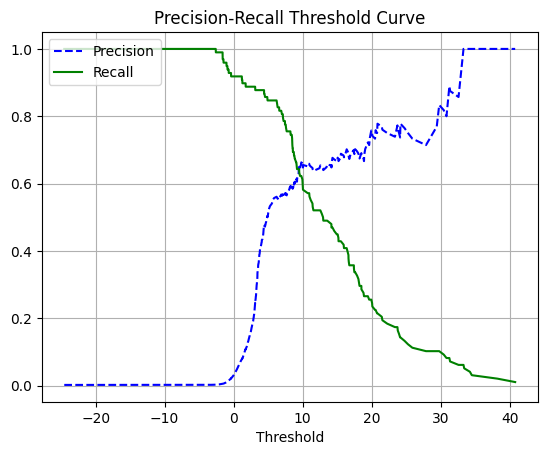

In [ ]:
from sklearn.metrics import precision_recall_curve

# Ambil probabilitas untuk kelas 1
y_scores = svc.decision_function(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.title("Precision-Recall Threshold Curve")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

Grafik ini digunakan untuk memvisualisasikan trade-off atau tarik-ulur antara Precision dan Recall berdasarkan perubahan ambang batas keputusan (threshold).

Dalam deteksi penipuan, kita sering kali harus memilih: ingin sangat ketat menangkap semua penipuan (Recall tinggi) namun berisiko banyak nasabah jujur terblokir, atau ingin sangat akurat (Precision tinggi) namun berisiko ada penipuan yang lolos.

Visualisasi ini membantu kita menentukan titik keseimbangan yang paling ideal sesuai dengan toleransi risiko yang diinginkan oleh sistem keamanan perbankan.